In [ ]:
!pip install koreanize_matplotlib -q

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import ttest_ind
import koreanize_matplotlib
import seaborn as sns

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
train = pd.read_csv('/content/drive/MyDrive/스트레스 지수 예측 해커톤/open/train.csv')

In [ ]:
train.head(3)

train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3000 entries, 0 to 2999
Data columns (total 18 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   ID                        3000 non-null   object 
 1   gender                    3000 non-null   object 
 2   age                       3000 non-null   int64  
 3   height                    3000 non-null   float64
 4   weight                    3000 non-null   float64
 5   cholesterol               3000 non-null   float64
 6   systolic_blood_pressure   3000 non-null   int64  
 7   diastolic_blood_pressure  3000 non-null   int64  
 8   glucose                   3000 non-null   float64
 9   bone_density              3000 non-null   float64
 10  activity                  3000 non-null   object 
 11  smoke_status              3000 non-null   object 
 12  medical_history           1711 non-null   object 
 13  family_medical_history    1514 non-null   object 
 14  sleep_pa

In [ ]:
print('데이터 타입:')
print(train.dtypes)
print(f'\n결측치: {train.isnull().sum().sum()}')

데이터 타입:
ID                           object
gender                       object
age                           int64
height                      float64
weight                      float64
cholesterol                 float64
systolic_blood_pressure       int64
diastolic_blood_pressure      int64
glucose                     float64
bone_density                float64
activity                     object
smoke_status                 object
medical_history              object
family_medical_history       object
sleep_pattern                object
edu_level                    object
mean_working                float64
stress_score                float64
dtype: object

결측치: 4414


In [ ]:
train.describe()

,age,height,weight,cholesterol,systolic_blood_pressure,diastolic_blood_pressure,glucose,bone_density,mean_working,stress_score
count,3000.00000,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000,1968.000000,3000.000000
mean,53.06800,168.585687,72.486680,233.910523,146.144333,95.504000,126.467720,0.933367,8.716972,0.482130
std,20.67207,9.351876,13.167222,24.333434,15.845310,9.895283,18.536844,0.444783,1.628944,0.288252
min,17.00000,141.130000,36.320000,148.810000,97.000000,60.000000,70.050000,-0.220000,4.000000,0.000000
25%,35.00000,161.800000,63.035000,216.927500,135.000000,89.000000,113.912500,0.560000,8.000000,0.230000
50%,53.00000,168.115000,71.240000,234.255000,146.000000,95.000000,126.555000,0.940000,9.000000,0.480000
75%,72.00000,175.352500,81.832500,250.377500,158.000000,102.000000,139.180000,1.300000,10.000000,0.730000
max,89.00000,195.280000,120.880000,313.350000,191.000000,124.000000,185.740000,2.000000,16.000000,1.000000


In [ ]:
potential_zeros = []
zero_counts = (train[potential_zeros] == 0).sum()
print(zero_counts)

Series([], dtype: float64)


In [ ]:
missing_values = train.isnull().sum()
display(missing_values)

,0
ID,0
gender,0
age,0
height,0
weight,0
cholesterol,0
systolic_blood_pressure,0
diastolic_blood_pressure,0
glucose,0
bone_density,0


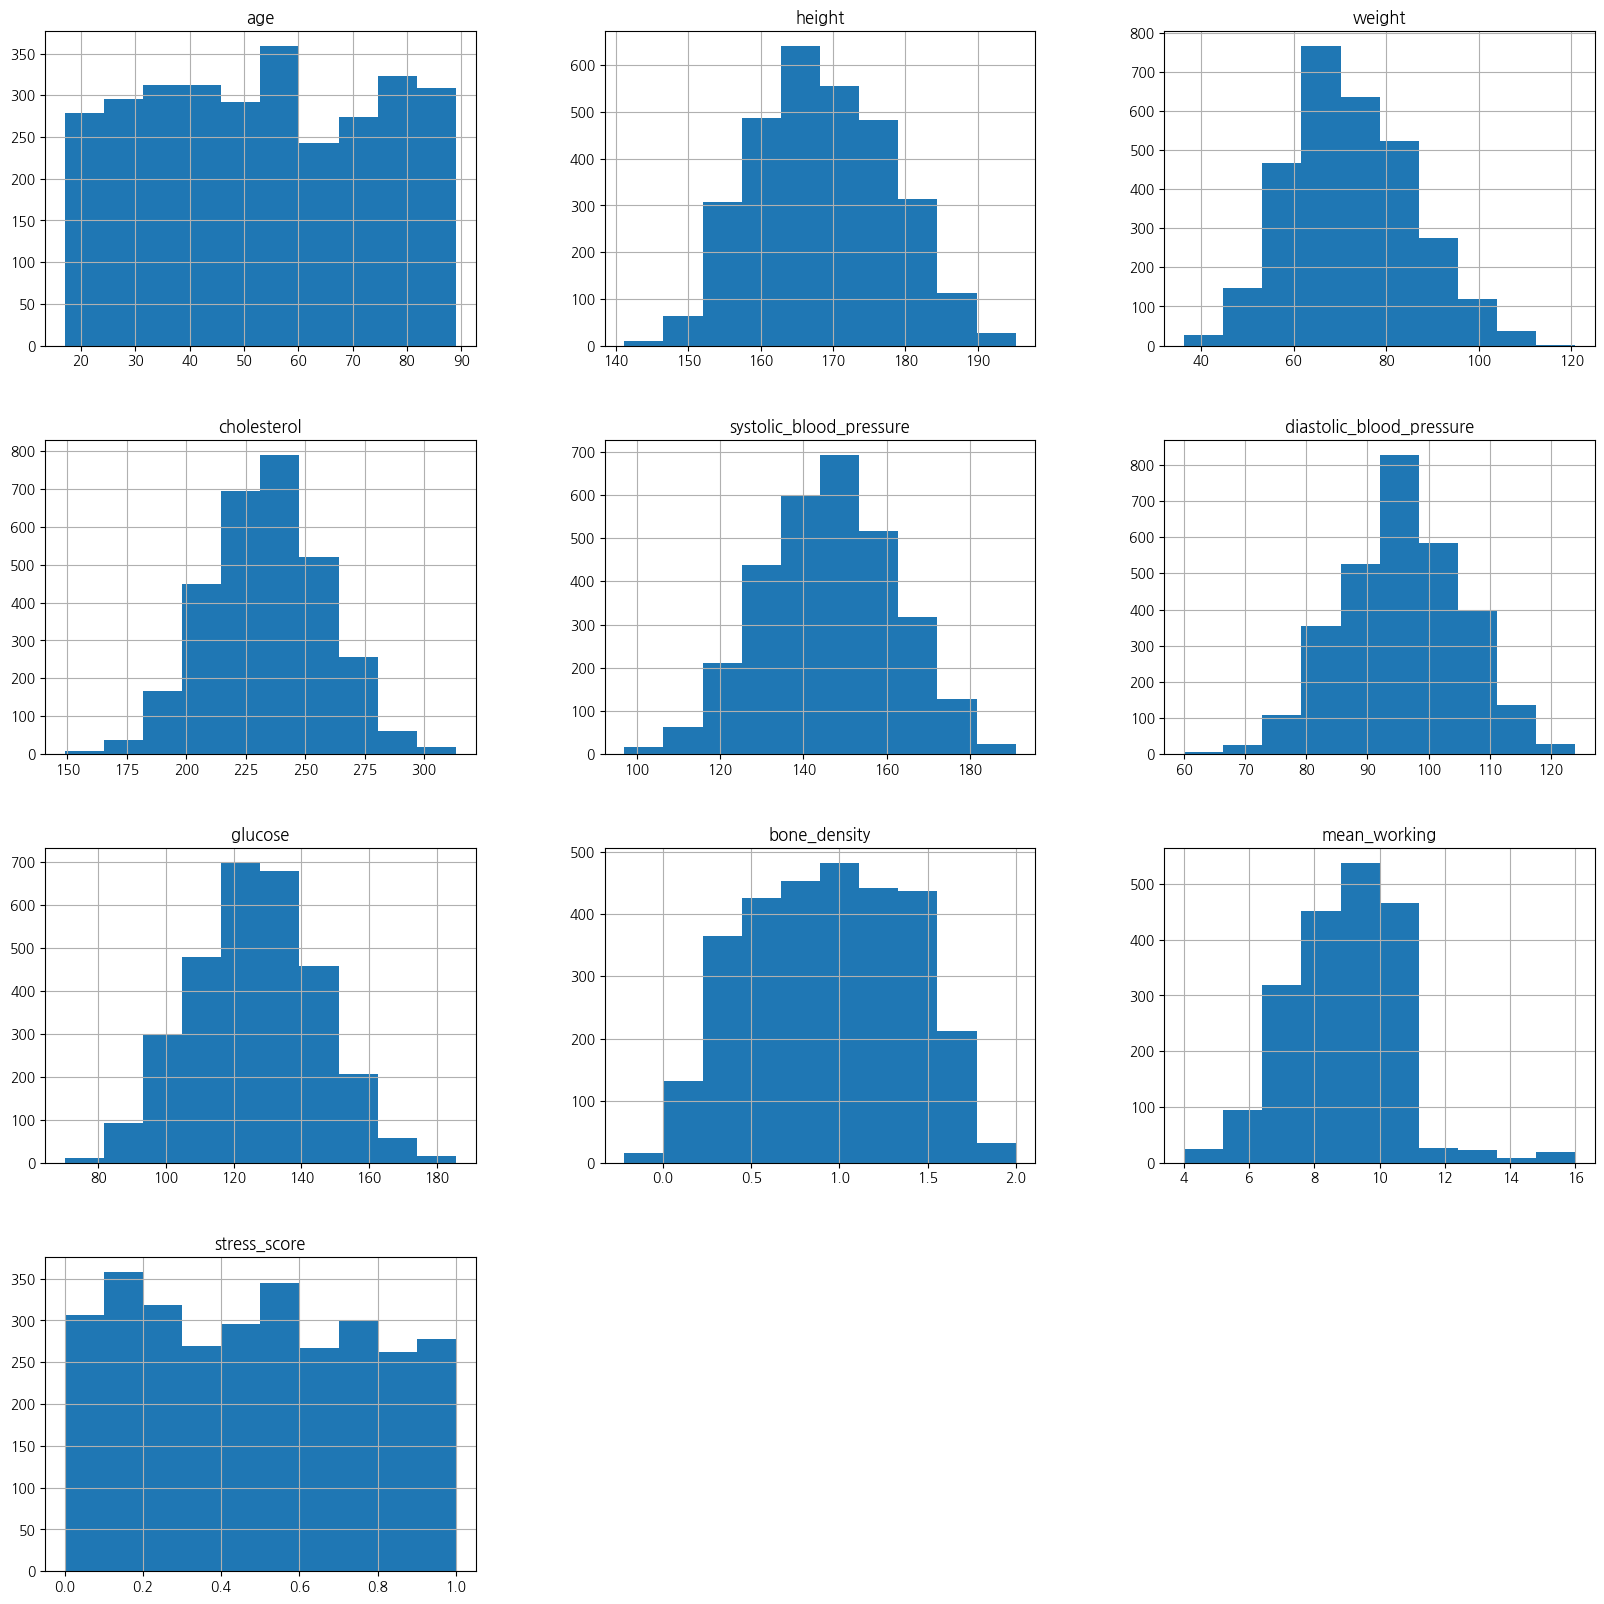

In [ ]:
train.hist(figsize = (20,20))
plt.show()

In [ ]:
train.head()

,ID,gender,age,height,weight,cholesterol,systolic_blood_pressure,diastolic_blood_pressure,glucose,bone_density,activity,smoke_status,medical_history,family_medical_history,sleep_pattern,edu_level,mean_working,stress_score
0,TRAIN_0000,F,72,161.49,58.47,279.84,165,100,143.35,0.87,moderate,ex-smoker,high blood pressure,diabetes,sleep difficulty,bachelors degree,NaN,0.63
1,TRAIN_0001,M,88,179.87,77.60,257.37,178,111,146.94,0.07,moderate,ex-smoker,NaN,diabetes,normal,graduate degree,NaN,0.83
2,TRAIN_0002,M,47,182.47,89.93,226.66,134,95,142.61,1.18,light,ex-smoker,NaN,NaN,normal,high school diploma,9.0,0.70
3,TRAIN_0003,M,69,185.78,68.63,206.74,158,92,137.26,0.48,intense,ex-smoker,high blood pressure,NaN,oversleeping,graduate degree,NaN,0.17
4,TRAIN_0004,F,81,164.63,71.53,255.92,171,116,129.37,0.34,moderate,ex-smoker,diabetes,diabetes,sleep difficulty,bachelors degree,NaN,0.36


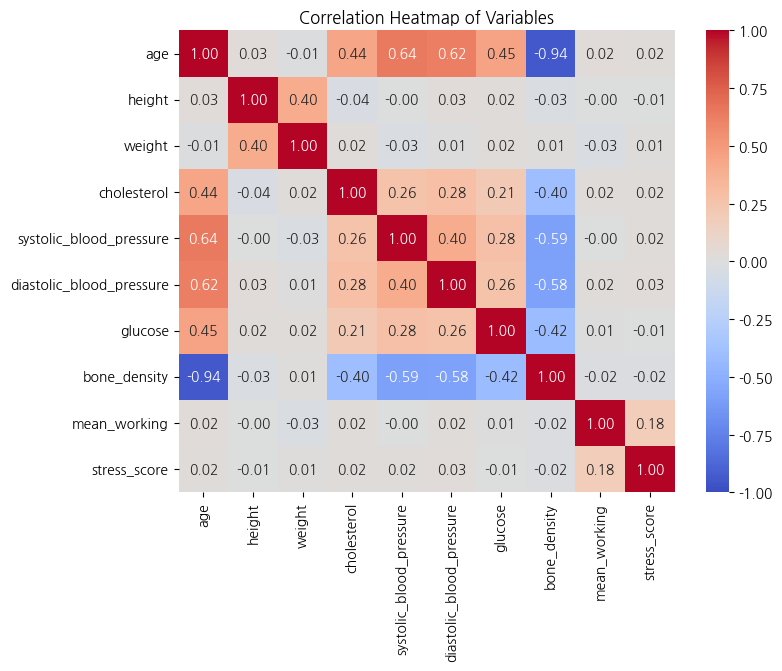

In [ ]:
corr_matrix = train.corr(numeric_only=True)

plt.figure(figsize=(8, 6))
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm', vmin=-1, vmax=1)
plt.title('Correlation Heatmap of Variables')
plt.show()

In [ ]:
# 1. 범주형(문자열) 컬럼들만 골라서 'cat_cols'라는 이름의 리스트로 만듭니다.
cat_cols = train.select_dtypes(include=['object']).columns

# 2. 이제 정의된 'cat_cols'를 사용하여 각 컬럼의 고유값 개수를 확인합니다.
for col in cat_cols:
    print(f"{col}: {train[col].nunique()} categories")

ID: 3000 categories
gender: 2 categories
activity: 3 categories
smoke_status: 3 categories
medical_history: 3 categories
family_medical_history: 3 categories
sleep_pattern: 3 categories
edu_level: 3 categories


In [ ]:
test = pd.read_csv('/content/drive/MyDrive/스트레스 지수 예측 해커톤/open/test.csv')

In [ ]:
from sklearn.preprocessing import OneHotEncoder

In [ ]:
# 1. 원-핫 인코더 생성 (범주형 컬럼 리스트 지정)
cat_cols = ['gender', 'activity', 'smoke_status', 'medical_history',
            'family_medical_history', 'sleep_pattern', 'edu_level']

# handle_unknown='ignore': 테스트에 새로운 범주가 나와도 에러 없이 0으로 처리
# sparse_output=False: 결과를 즉시 배열로 반환 (Pandas 결합 용이)
oh_encoder = OneHotEncoder(handle_unknown='ignore', sparse_output=False)

# 2. Train 데이터로 기준 학습 및 변환
train_cat = oh_encoder.fit_transform(train[cat_cols])
train_cat_df = pd.DataFrame(train_cat, columns=oh_encoder.get_feature_names_out(cat_cols))

# 3. Test 데이터는 'transform'만 수행 (학습 시 기준 그대로 적용)
test_cat = oh_encoder.transform(test[cat_cols])
test_cat_df = pd.DataFrame(test_cat, columns=oh_encoder.get_feature_names_out(cat_cols))

# 4. 기존 수치형 컬럼과 합치기 (ID, target 제외)
train_final = pd.concat([train.drop(columns=cat_cols), train_cat_df], axis=1)
test_final = pd.concat([test.drop(columns=cat_cols), test_cat_df], axis=1)

In [ ]:
display(train.head())
display(test.head())

,ID,gender,age,height,weight,cholesterol,systolic_blood_pressure,diastolic_blood_pressure,glucose,bone_density,activity,smoke_status,medical_history,family_medical_history,sleep_pattern,edu_level,mean_working,stress_score
0,TRAIN_0000,F,72,161.49,58.47,279.84,165,100,143.35,0.87,moderate,ex-smoker,high blood pressure,diabetes,sleep difficulty,bachelors degree,NaN,0.63
1,TRAIN_0001,M,88,179.87,77.60,257.37,178,111,146.94,0.07,moderate,ex-smoker,NaN,diabetes,normal,graduate degree,NaN,0.83
2,TRAIN_0002,M,47,182.47,89.93,226.66,134,95,142.61,1.18,light,ex-smoker,NaN,NaN,normal,high school diploma,9.0,0.70
3,TRAIN_0003,M,69,185.78,68.63,206.74,158,92,137.26,0.48,intense,ex-smoker,high blood pressure,NaN,oversleeping,graduate degree,NaN,0.17
4,TRAIN_0004,F,81,164.63,71.53,255.92,171,116,129.37,0.34,moderate,ex-smoker,diabetes,diabetes,sleep difficulty,bachelors degree,NaN,0.36


,ID,gender,age,height,weight,cholesterol,systolic_blood_pressure,diastolic_blood_pressure,glucose,bone_density,activity,smoke_status,medical_history,family_medical_history,sleep_pattern,edu_level,mean_working
0,TEST_0000,F,72,161.95,77.66,312.36,137,112,131.16,0.51,moderate,current-smoker,high blood pressure,heart disease,oversleeping,graduate degree,NaN
1,TEST_0001,F,84,152.35,58.70,269.54,162,95,129.36,0.51,intense,current-smoker,NaN,NaN,normal,graduate degree,NaN
2,TEST_0002,F,45,164.09,76.71,209.08,146,91,169.21,1.13,light,ex-smoker,diabetes,heart disease,sleep difficulty,bachelors degree,6.0
3,TEST_0003,M,58,165.06,76.34,246.52,146,98,133.78,0.52,light,current-smoker,heart disease,heart disease,sleep difficulty,high school diploma,10.0
4,TEST_0004,F,35,158.17,65.60,181.24,142,80,73.93,1.42,moderate,ex-smoker,diabetes,heart disease,oversleeping,NaN,7.0


In [ ]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error

In [ ]:
# 1. 독립변수(X)와 종속변수(y) 분리
# ID와 정답(stress_score) 컬럼은 학습에서 제외합니다.
X_train = train_final.drop(['ID', 'stress_score'], axis=1)
y_train = train_final['stress_score']

# 2. 테스트 데이터 준비 (ID 컬럼만 제외, test에는 stress_score가 없다고 가정)
X_test = test_final.drop(['ID'], axis=1)

# 3. 모델 생성 및 학습 (이전 최적 설정 적용)
rf_model = RandomForestRegressor(
    n_estimators=500,
    random_state=42
)
rf_model.fit(X_train, y_train)

# 4. 테스트 데이터에 대한 예측
final_predictions = rf_model.predict(X_test).round(2)

print(final_predictions[:5])

[0.49 0.75 0.39 0.47 0.53]


In [ ]:
submission = pd.read_csv('/content/drive/MyDrive/스트레스 지수 예측 해커톤/open/sample_submission.csv')

In [ ]:
submission['stress_score'] = final_predictions
submission.head()

,ID,stress_score
0,TEST_0000,0.49
1,TEST_0001,0.75
2,TEST_0002,0.39
3,TEST_0003,0.47
4,TEST_0004,0.53


In [ ]:
submit = pd.read_csv('/content/drive/MyDrive/스트레스 지수 예측 해커톤/open/sample_submission.csv')
submit['stress_score'] = final_predictions
submit.to_csv('/content/drive/MyDrive/스트레스 지수 예측 해커톤/open/sample_submission.csv', index=False)